# 04 · Threat pattern analysis

Runs `src/threat_patterns.py`: traffic profiles per attack type, protocol/service heatmaps, state anomalies, a duration-bin substitute for time spikes, connection-context (recon) behaviour, TTL fingerprints, chi-square and Mann-Whitney U tests with effect sizes, and a Spearman correlation heatmap.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
SRC = Path.cwd().parent / 'src' if (Path.cwd().parent / 'src').exists() else Path.cwd() / 'src'
sys.path.insert(0, str(SRC))
import pandas as pd, json
from IPython.display import Image, Markdown, display
from config import FIG_DIR, METRICS_DIR, REPORTS_DIR, EXPORT_DIR
pd.set_option('display.max_columns', 60, 'display.width', 200)
def show(name, width=900):
    display(Image(filename=str(FIG_DIR / f'{name}.png'), width=width))

In [2]:
import threat_patterns
res = threat_patterns.run()


PHASE 5 - THREAT PATTERN ANALYSIS


feature  median_attack  median_normal  rank_biserial     effect
 sbytes     200.000000    1040.000000        -0.4045     medium
 dbytes       0.000000     642.000000        -0.5330      large
    dur       0.000009       0.053938        -0.3079     medium
  spkts       2.000000      10.000000        -0.4012     medium
  dpkts       0.000000       8.000000        -0.5291      large
   rate  111111.107200     642.325743         0.3762     medium
   sttl     254.000000      31.000000         0.6668      large
  smean      65.000000      73.000000        -0.0768 negligible
Chi-square attack_cat x proto: chi2=232,697, dof=72, p=0.00e+00, Cramer's V=0.336
Chi-square attack_cat x service: chi2=237,965, dof=108, p=0.00e+00, Cramer's V=0.320


* 05_profile_boxplots: Generic attacks are tiny and fast: median sbytes 114 B and median duration 0.000008s vs 1040 B / 0.054s for normal flows. Exploits carry the heaviest payloads among attacks (median sbytes 842 B). Volume alone does not separate attacks: several attack classes overlap heavily with normal traffic.

* 05_proto_service_heatmap: DNS is dominated by Generic attacks (83.4% of DNS flows). The 'unas' protocol is 100% malicious (15,599 flows, mostly Exploits 42%, DoS 34%, Fuzzers 7%). 'other' (rare) protocols are almost entirely attacks (99.6%), while ARP is entirely normal.

* 05_state_attack_rate: INT (interrupted/no-reply) connections have a 91.2% attack rate across 116,438 flows, versus 7.0% for CON (established, two-way) flows. Half-open / unanswered connections are the strongest single state signal.

* 05_duration_bins: No timestamps exist in this release, so hourly/daily spikes cannot be measured. As a substitute, sub-millisecond flows (112,982) are 91.3% attacks, wh

### 05_profile_boxplots
Generic attacks are tiny and fast: median sbytes 114 B and median duration 0.000008s vs 1040 B / 0.054s for normal flows. Exploits carry the heaviest payloads among attacks (median sbytes 842 B). Volume alone does not separate attacks: several attack classes overlap heavily with normal traffic.

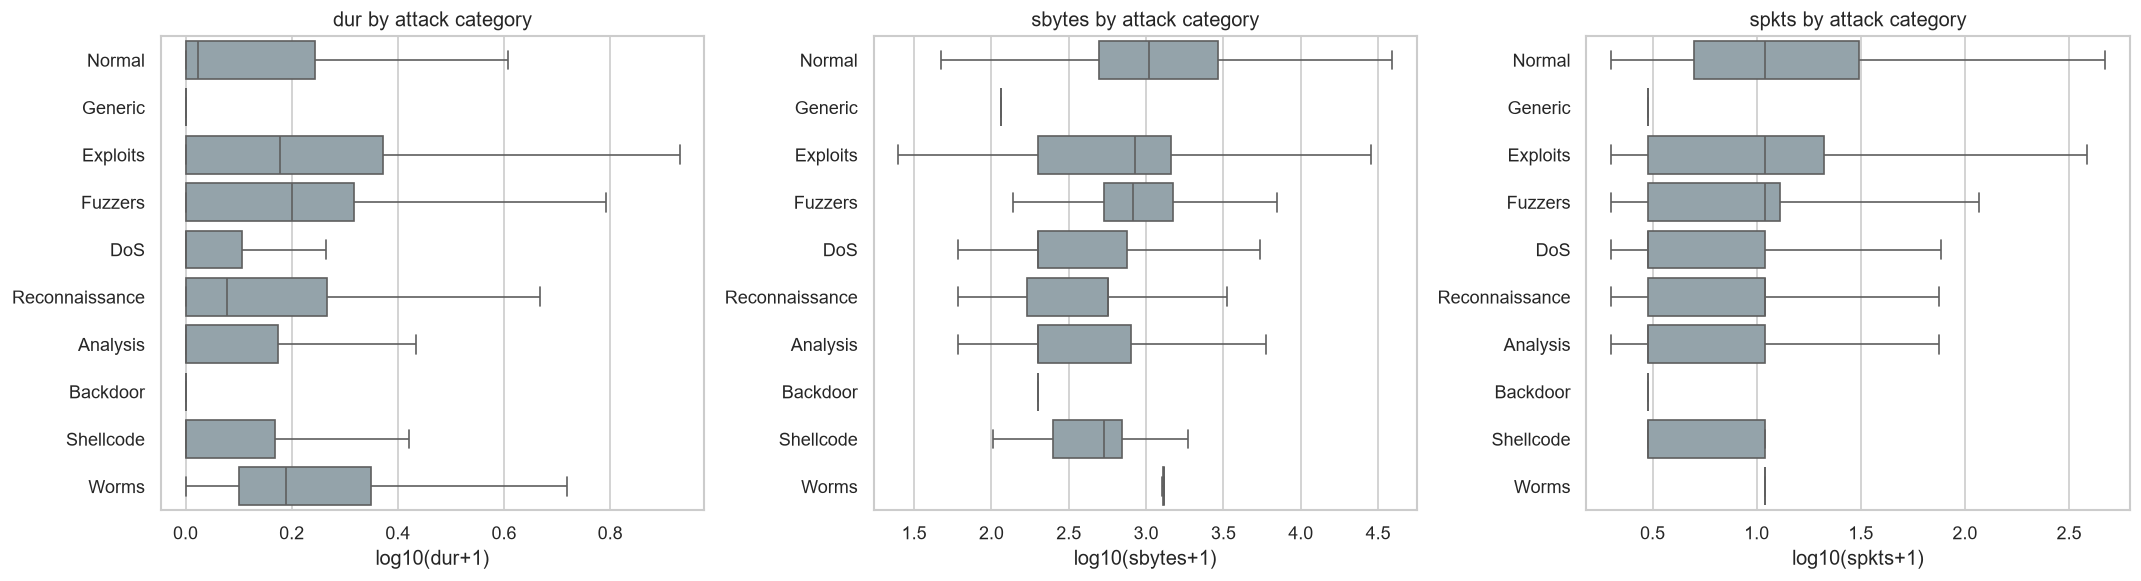

### 05_proto_service_heatmap
DNS is dominated by Generic attacks (83.4% of DNS flows). The 'unas' protocol is 100% malicious (15,599 flows, mostly Exploits 42%, DoS 34%, Fuzzers 7%). 'other' (rare) protocols are almost entirely attacks (99.6%), while ARP is entirely normal.

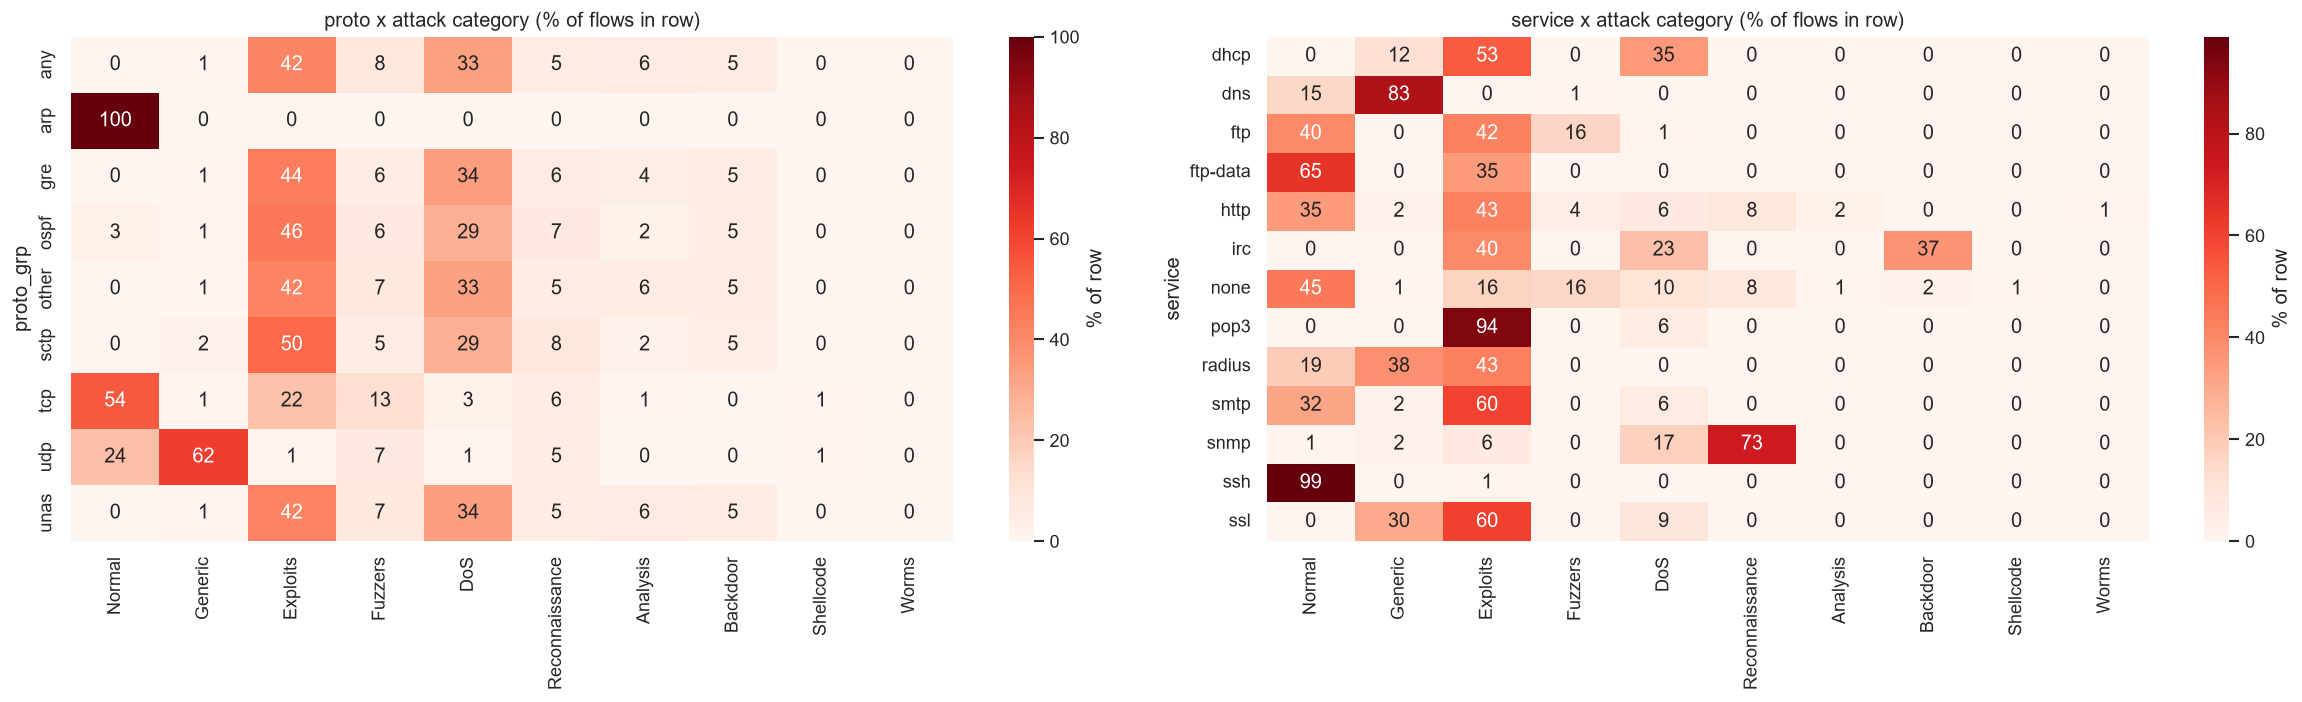

### 05_state_attack_rate
INT (interrupted/no-reply) connections have a 91.2% attack rate across 116,438 flows, versus 7.0% for CON (established, two-way) flows. Half-open / unanswered connections are the strongest single state signal.

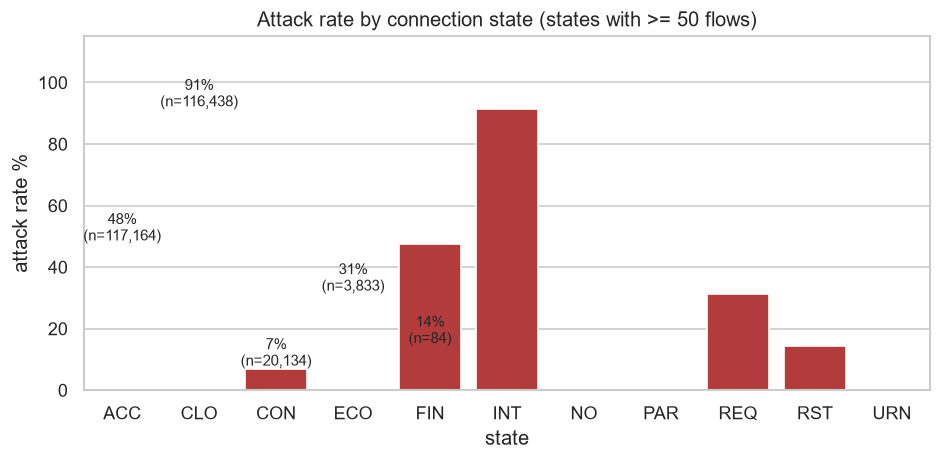

### 05_duration_bins
No timestamps exist in this release, so hourly/daily spikes cannot be measured. As a substitute, sub-millisecond flows (112,982) are 91.3% attacks, while 1-100 ms flows are almost all normal (0.1% and 1.2%) - a burst-like, automated signature.

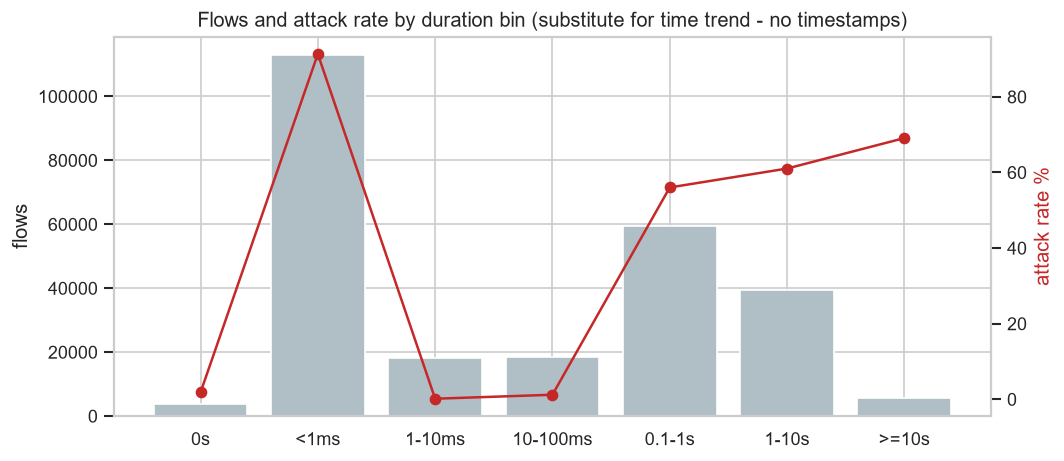

### 05_recon_context
Generic attacks are highly repetitive: mean ct_dst_src_ltm 24.0 vs 3.9 for normal (same host pair hammered repeatedly). Reconnaissance flows, by contrast, show LOW repetition (2.1) - consistent with probes spread across many targets. Without IPs/ports, true distinct-port scan counts cannot be computed.

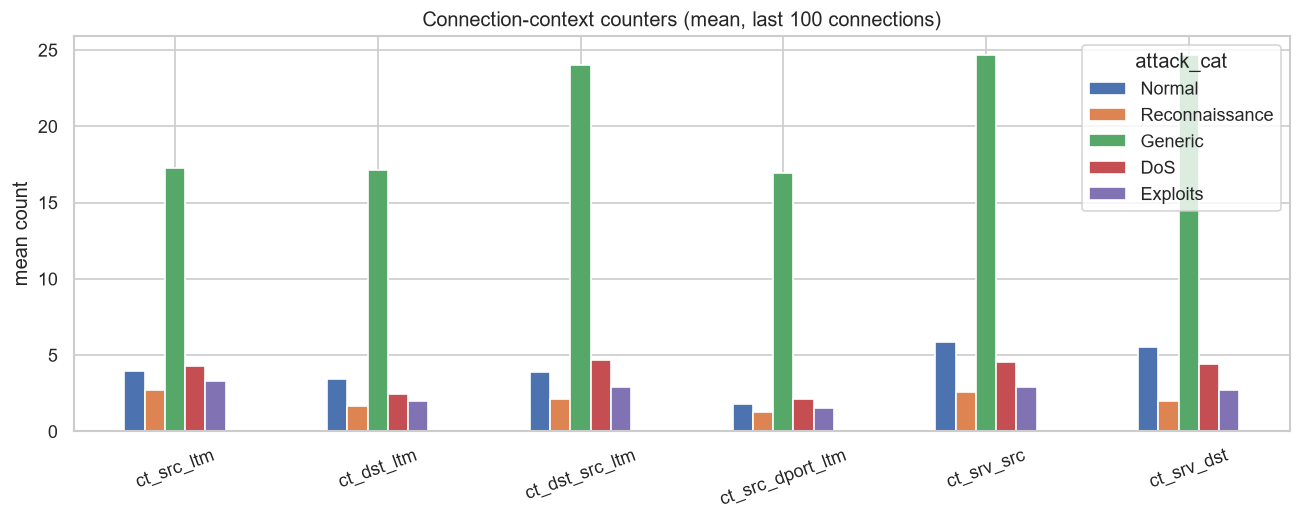

### 05_ttl_fingerprint
sttl/dttl = 254/0 covers 115,660 flows with a 92.4% attack rate, while 31/29 (56,112 flows) is 0% attacks. These TTLs reflect the lab's attack-generator topology, so models will exploit them - a known UNSW-NB15 artefact that will not transfer to other networks.

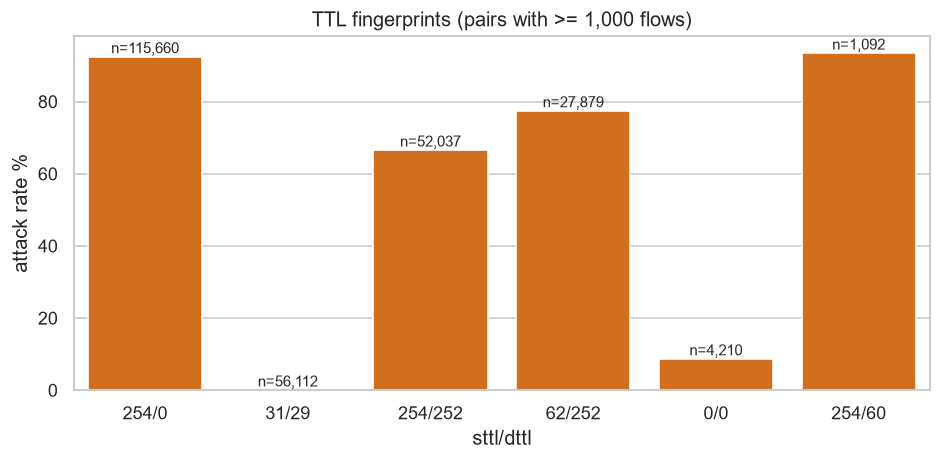

### 05_correlation_heatmap
Strongest monotonic correlates of the attack label: sttl (+0.66), ct_state_ttl (+0.59), dload (-0.58), dmean (-0.51), dbytes (-0.46). Byte/packet counters are strongly inter-correlated (redundant), which matters for linear models.

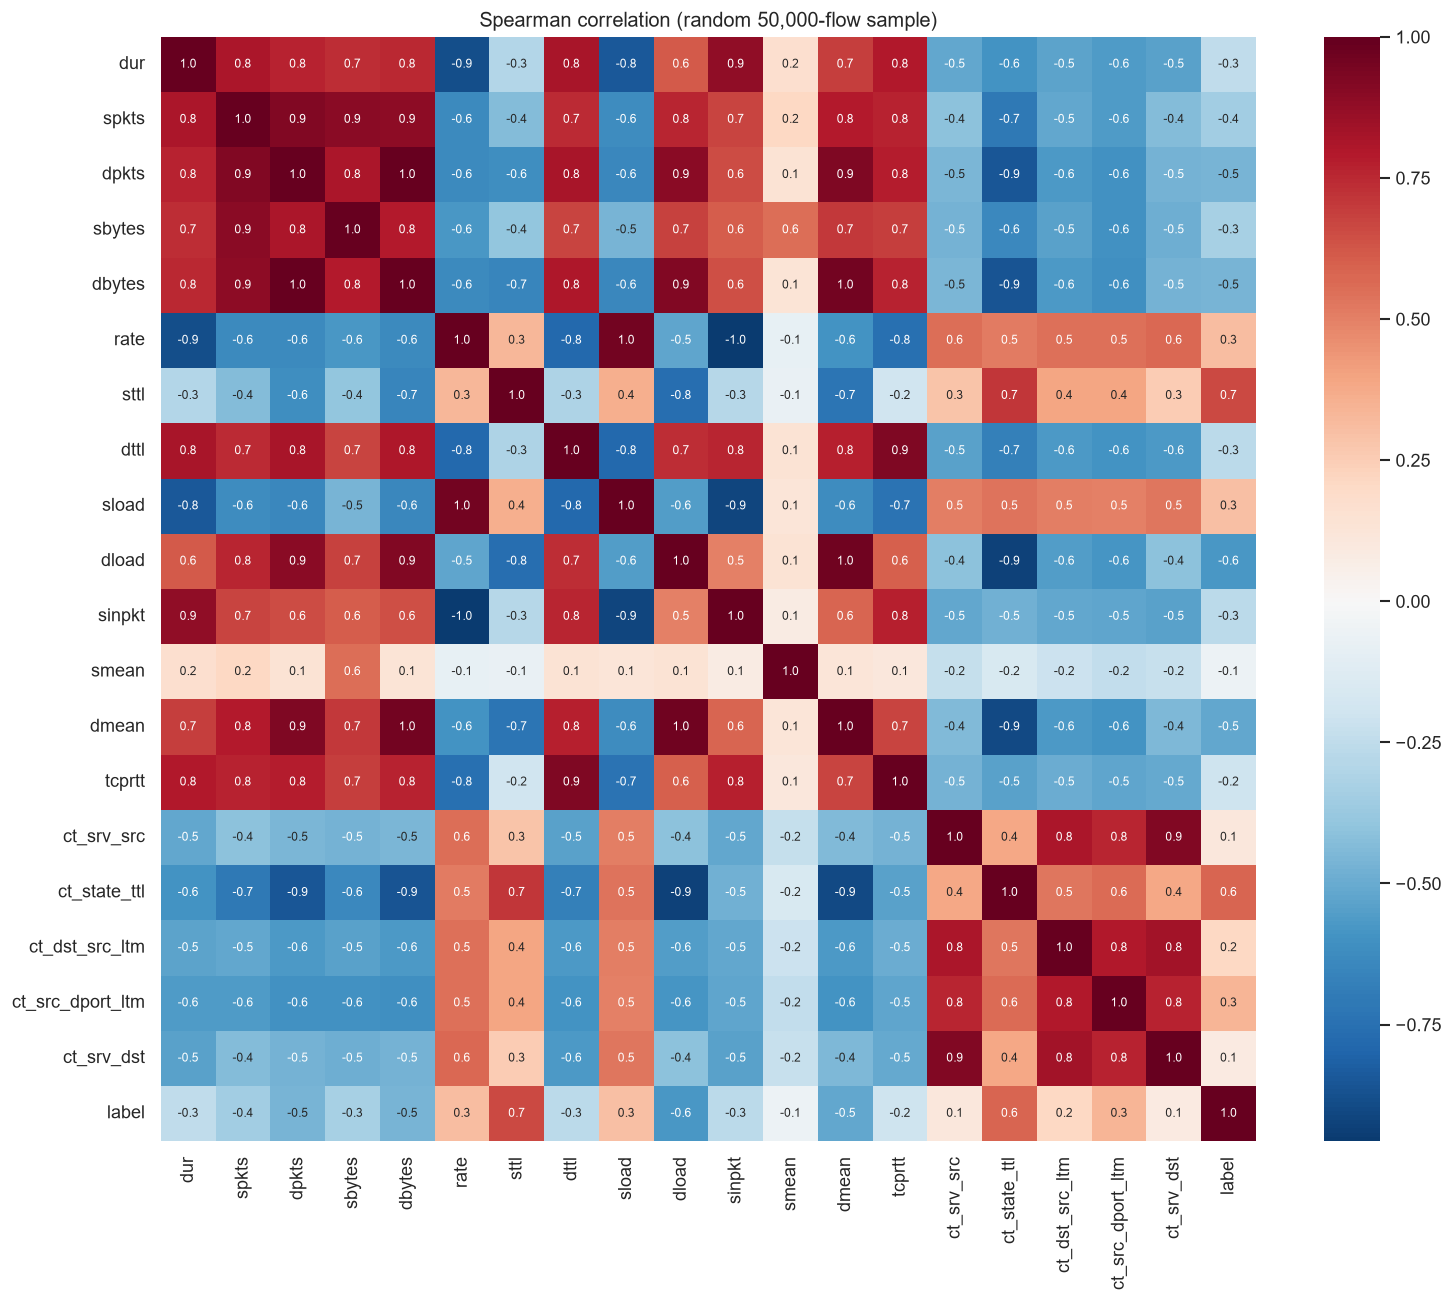

### statistical_tests
Chi-square shows attack type depends strongly on protocol (chi2=232,697, dof=72, p~0 (below float precision), Cramer's V=0.34) and service (Cramer's V=0.32). Mann-Whitney U: attack flows send fewer bytes than normal flows (median sbytes 200 vs 1040, rank-biserial -0.40) and receive far fewer (dbytes r=-0.53, large). With n=257,673 every p-value is ~0, so effect sizes - not p-values - indicate practical importance.

In [3]:
for f in res['findings']:
    display(Markdown(f"### {f['figure']}\n{f['text']}"))
    if f['figure'].startswith('05_'):
        show(f['figure'], 1000)

## Mann-Whitney U with rank-biserial effect sizes

In [4]:
pd.read_csv(METRICS_DIR / 'mann_whitney.csv')

,feature,median_attack,median_normal,U,p_value,rank_biserial,effect
0,sbytes,200.000000,1040.000000,4.559983e+09,0.000000e+00,-0.4045,medium
1,dbytes,0.000000,642.000000,3.576253e+09,0.000000e+00,-0.5330,large
2,dur,0.000009,0.053938,5.299603e+09,0.000000e+00,-0.3079,medium
3,spkts,2.000000,10.000000,4.584878e+09,0.000000e+00,-0.4012,medium
4,dpkts,0.000000,8.000000,3.605667e+09,0.000000e+00,-0.5291,large
5,rate,111111.107200,642.325743,1.053772e+10,0.000000e+00,0.3762,medium
6,sttl,254.000000,31.000000,1.276355e+10,0.000000e+00,0.6668,large
7,smean,65.000000,73.000000,7.069340e+09,6.365347e-234,-0.0768,negligible


In [5]:
res['chi_square']

{'attack_cat_vs_proto': {'chi2': np.float64(232696.97646868168),
  'p_value': np.float64(0.0),
  'dof': 72,
  'cramers_v': 0.335981929422424},
 'attack_cat_vs_service': {'chi2': np.float64(237965.04125053828),
  'p_value': np.float64(0.0),
  'dof': 108,
  'cramers_v': 0.3203324008807305}}